In [1]:
import pandas as pd

#### Importing data
This code imports the data made in another jupyter notebook and drops the first column name, this column only contained a single counter value which pandas also keeps track of, so this was unnessacary. Next I show the first 5 rows to make sure it got imported correctly.

In [2]:
df = pd.read_csv("5kfiles_kt1.csv")
df = df.drop(columns=["Unnamed: 0"])
df.head(5)

,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,1565096190868,1,q5012,b,38000,1
1,1565096221062,2,q4706,c,24000,1
2,1565096293432,3,q4366,b,68000,1
3,1565096339668,4,q4829,a,42000,1
4,1565096401774,5,q6528,b,59000,1


In [3]:
df['question_id'] = df['question_id'].str.lstrip('q').astype(int)

In [4]:
df.head()

,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,1565096190868,1,5012,b,38000,1
1,1565096221062,2,4706,c,24000,1
2,1565096293432,3,4366,b,68000,1
3,1565096339668,4,4829,a,42000,1
4,1565096401774,5,6528,b,59000,1


### Question awnsers
Next I took a look at the question awnsers, in the contents table there is the correct solution to a question but I wanted to check out if I could find the correct solution based on user awnsers.

In [5]:
question_answers = df.groupby(['question_id', 'user_answer']).size()
question_answers = question_answers.unstack(fill_value=0)
question_answers

user_answer,a,b,c,d
question_id,,,,
1,1,87,2,1
2,104,17,1,1
3,6,239,105,62
4,1,204,37,9
5,42,25,148,21
...,...,...,...,...
18139,2,23,1,0
18140,22,3,0,0
18141,22,0,2,0


In [6]:
user_answer_winner = question_answers.idxmax(axis=1)
user_answer_winner = user_answer_winner.reset_index()
user_answer_winner.columns = ['question_id', 'answer']

In [7]:
user_answer_winner.head()

,question_id,answer
0,1,b
1,2,a
2,3,b
3,4,b
4,5,c


In [8]:
df_question_content = pd.read_csv("contents\\questions.csv")
df_question_content.head()

,question_id,bundle_id,explanation_id,correct_answer,part,tags,deployed_at
0,q1,b1,e1,b,1,1;2;179;181,1558093217098
1,q2,b2,e2,a,1,15;2;182,1558093219720
2,q3,b3,e3,b,1,14;2;179;183,1558093222784
3,q4,b4,e4,b,1,9;2;179;184,1558093225357
4,q5,b5,e5,c,1,8;2;179;181,1558093228439


In [9]:
comparison_df = df_question_content[['question_id', 'correct_answer']].merge(
    user_answer_winner[['question_id', 'answer']],
    on='question_id',
    how='inner'
)
comparison_df['matches'] = comparison_df['correct_answer'] == comparison_df['answer']
print(comparison_df)

mismatches = comparison_df[~comparison_df['matches']]
print(f"total amount of mismatches: {len(mismatches)}")

ValueError: You are trying to merge on str and int32 columns for key 'question_id'. If you wish to proceed you should use pd.concat

### python bkt


In [10]:
df_question_content.head()

,question_id,bundle_id,explanation_id,correct_answer,part,tags,deployed_at
0,q1,b1,e1,b,1,1;2;179;181,1558093217098
1,q2,b2,e2,a,1,15;2;182,1558093219720
2,q3,b3,e3,b,1,14;2;179;183,1558093222784
3,q4,b4,e4,b,1,9;2;179;184,1558093225357
4,q5,b5,e5,c,1,8;2;179;181,1558093228439


In [11]:
df_question_content['tag_list'] = df_question_content['tags'].str.split(';')
df_question_content['question_id_int'] = df_question_content['question_id'].str.lstrip('q').astype(int)
df_question_content.head(5)

,question_id,bundle_id,explanation_id,correct_answer,part,tags,deployed_at,tag_list,question_id_int
0,q1,b1,e1,b,1,1;2;179;181,1558093217098,"[1, 2, 179, 181]",1
1,q2,b2,e2,a,1,15;2;182,1558093219720,"[15, 2, 182]",2
2,q3,b3,e3,b,1,14;2;179;183,1558093222784,"[14, 2, 179, 183]",3
3,q4,b4,e4,b,1,9;2;179;184,1558093225357,"[9, 2, 179, 184]",4
4,q5,b5,e5,c,1,8;2;179;181,1558093228439,"[8, 2, 179, 181]",5


In [12]:
questions_exploded = df_question_content.explode('tag_list')
questions_exploded['skill_name'] = questions_exploded['tag_list']

In [13]:
question_skills = questions_exploded[['question_id_int', 'skill_name', 'correct_answer']].drop_duplicates()
question_skills = question_skills.rename(columns={'question_id_int':'question_id'})
question_skills.info

<bound method DataFrame.info of        question_id skill_name correct_answer
0                1          1              b
0                1          2              b
0                1        179              b
0                1        181              b
1                2         15              a
...            ...        ...            ...
13168        18143         27              c
13168        18143         24              c
13168        18143         26              c
13168        18143        183              c
13168        18143        182              c

[28758 rows x 3 columns]>

In [14]:
question_skills.dtypes

question_id       int32
skill_name          str
correct_answer      str
dtype: object

In [15]:
df.dtypes

timestamp       int64
solving_id      int64
question_id     int32
user_answer       str
elapsed_time    int64
user_id         int64
dtype: object

In [16]:
df_merged = pd.merge(
    df,
    question_skills,
    on='question_id',
    how='left'
)

df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 3361609 entries, 0 to 3361608
Data columns (total 8 columns):
 #   Column          Dtype
---  ------          -----
 0   timestamp       int64
 1   solving_id      int64
 2   question_id     int32
 3   user_answer     str  
 4   elapsed_time    int64
 5   user_id         int64
 6   skill_name      str  
 7   correct_answer  str  
dtypes: int32(1), int64(4), str(3)
memory usage: 207.9 MB


In [17]:
df_merged['correct'] = (df_merged['user_answer'] == df_merged['correct_answer']).astype(int)

### order id per student


In [18]:
df_merged.head(20)

,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id,skill_name,correct_answer,correct
0,1565096190868,1,5012,b,38000,1,74,c,0
1,1565096221062,2,4706,c,24000,1,71,c,1
2,1565096293432,3,4366,b,68000,1,103,b,1
3,1565096339668,4,4829,a,42000,1,83,c,0
4,1565096401774,5,6528,b,59000,1,90,d,0
5,1565096463370,6,4793,a,58000,1,82,b,0
6,1565096501746,7,6488,a,35000,1,77,a,1
7,1565097101361,8,356,b,23000,1,30,b,1
8,1565097101361,8,356,b,23000,1,34,b,1
9,1565097101361,8,356,b,23000,1,42,b,1


In [19]:
df_merged = df_merged.sort_values(['user_id', 'timestamp'])

df_merged['order_id'] = df_merged.groupby('user_id').cumcount() + 1
df_merged.head(20)

,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id,skill_name,correct_answer,correct,order_id
0,1565096190868,1,5012,b,38000,1,74,c,0,1
1,1565096221062,2,4706,c,24000,1,71,c,1,2
2,1565096293432,3,4366,b,68000,1,103,b,1,3
3,1565096339668,4,4829,a,42000,1,83,c,0,4
4,1565096401774,5,6528,b,59000,1,90,d,0,5
5,1565096463370,6,4793,a,58000,1,82,b,0,6
6,1565096501746,7,6488,a,35000,1,77,a,1,7
7,1565097101361,8,356,b,23000,1,30,b,1,8
8,1565097101361,8,356,b,23000,1,34,b,1,9
9,1565097101361,8,356,b,23000,1,42,b,1,10


In [20]:
df_bkt = df_merged[['user_id', 'skill_name', 'correct', 'order_id']]

df_bkt.head(5)

,user_id,skill_name,correct,order_id
0,1,74,0,1
1,1,71,1,2
2,1,103,1,3
3,1,83,0,4
4,1,90,0,5


In [21]:
import sklearn
import importlib.metadata

print("sklearn:", sklearn.__version__)
print("pyBKT:", importlib.metadata.version("pyBKT"))

sklearn: 1.3.2
pyBKT: 1.4.2


In [22]:
from pyBKT.models import Model

model = Model(seed=42, num_fits=45)
model.fit(data=df_bkt)



c:\Users\bramm\S3C2-studentgrades\.venv\Lib\site-packages\pyBKT\fit\M_step.py:61: RuntimeWarning: invalid value encountered in divide
  model['pi_0'] = init_softcounts[:] / np.sum(init_softcounts[:])


In [23]:
params = model.params()
print(params.keys)



<bound method NDFrame.keys of                         value
skill param   class          
74    prior   default     NaN
      learns  default 1.00000
      guesses default 0.50000
      slips   default 0.50000
      forgets default 0.00000
...                       ...
186   prior   default     NaN
      learns  default 1.00000
      guesses default 0.50000
      slips   default 0.50000
      forgets default 0.00000

[945 rows x 1 columns]>


In [24]:
predictions = model.predict(data=df_bkt)
print(predictions[['user_id', 'skill_name', 'correct', 'correct_predictions']].head())

   user_id skill_name  correct  correct_predictions
0        1         74        0                  NaN
1        1         71        1                  NaN
2        1        103        1                  NaN
3        1         83        0                  NaN
4        1         90        0                  NaN


In [25]:
# Try fitting just one skill that has enough data
skill_counts = df_bkt['skill_name'].value_counts()
print("Top 5 skills by count:")
print(skill_counts.head())

# Pick the most frequent skill
top_skill = skill_counts.index[0]
print(f"\nTrying to fit skill: {top_skill}")

# Fit model for just that one skill
model_single = Model(seed=42, num_fits=5)
model_single.fit(data=df_bkt, skills=top_skill)

# Check if it worked
params_single = model_single.params()
print(f"Params for {top_skill}: {params_single.get(top_skill, 'NOT FOUND')}")

# Try predicting
preds_single = model_single.predict(data=df_bkt[df_bkt['skill_name'] == top_skill])
print(preds_single[['user_id', 'skill_name', 'correct', 'correct_predictions']].head(10))

Top 5 skills by count:
skill_name
183    277881
181    238052
182    202454
184    185994
179    132738
Name: count, dtype: int64

Trying to fit skill: 183


c:\Users\bramm\S3C2-studentgrades\.venv\Lib\site-packages\pyBKT\fit\M_step.py:61: RuntimeWarning: invalid value encountered in divide
  model['pi_0'] = init_softcounts[:] / np.sum(init_softcounts[:])


Params for 183: NOT FOUND
     user_id skill_name  correct  correct_predictions
11         1        183        1                  NaN
29         1        183        1              0.00000
52         1        183        1              0.00000
78         1        183        1              0.00000
82         1        183        1              0.00000
87         1        183        1              0.00000
91         1        183        1              0.00000
95         1        183        1              0.00000
100        1        183        1              0.00000
104        1        183        1              0.00000


### Custom BKT Implementation

In [21]:
import numpy as np
import pandas as pd

# =============================================================================
# Custom BKT — Baum-Welch (forward-backward) EM
# =============================================================================
# The original version of this cell only ran a *forward* pass and tried to
# accumulate soft counts from filtered estimates p_l and p_l_given_obs. That
# math is wrong: every M-step update algebraically simplifies to
# `new_param == old_param`, so the parameters never moved from their
# initial values (and guess/slip slowly drifted into the clip floor). The
# symptom was that every skill ended up with identical params:
#   prior=0.50, learn=0.10, guess=0.01, slip=0.01
#
# BKT is a 2-state HMM and EM for it requires the FORWARD-BACKWARD
# (Baum-Welch) algorithm to get the true posteriors gamma_t(k) and the
# transition posteriors xi_t(j,k). Those are the right soft counts.
# =============================================================================


def forward_pass(sequence, prior, learn, guess, slip):
    """Filtered P(correct) at each step — used for predictions, not for fitting."""
    p_l = prior
    predictions = []
    for correct in sequence:
        p_correct = p_l * (1 - slip) + (1 - p_l) * guess
        predictions.append(p_correct)
        if correct == 1:
            num = p_l * (1 - slip)
            den = num + (1 - p_l) * guess
        else:
            num = p_l * slip
            den = num + (1 - p_l) * (1 - guess)
        p_l_given_obs = num / den if den > 0 else p_l
        p_l = p_l_given_obs + (1 - p_l_given_obs) * learn
    return predictions


def fit_skill(sequences, n_iter=100, tol=1e-5,
              init_prior=0.3, init_learn=0.1,
              init_guess=0.2, init_slip=0.1):
    """Fit BKT for one skill via Baum-Welch EM.

    HMM specification:
      state 0 = not learned, state 1 = learned (no forgetting)
      Transition: A[0,0]=1-learn, A[0,1]=learn, A[1,0]=0, A[1,1]=1
      Emissions:  P(correct|0)=guess, P(correct|1)=1-slip
    """
    seqs = [np.asarray(s, dtype=np.int8) for s in sequences if len(s) > 0]
    if not seqs:
        return {'prior': init_prior, 'learn': init_learn,
                'guess': init_guess, 'slip': init_slip,
                'n_sequences': 0, 'n_obs': 0,
                'log_likelihood': float('nan'), 'iterations': 0}

    prior, learn, guess, slip = init_prior, init_learn, init_guess, init_slip
    prev_ll = -np.inf

    for it in range(n_iter):
        # Accumulators
        sum_prior_post = 0.0           # for prior: gamma_0(1) averaged
        n_seq = 0
        sum_xi_01 = 0.0                # learn numerator
        sum_gamma0_trans = 0.0         # learn denominator: gamma_t(0), t<T-1
        sum_correct_nl = 0.0           # guess numerator
        sum_total_nl = 0.0             # guess denominator: total gamma(0)
        sum_wrong_l = 0.0              # slip numerator
        sum_total_l = 0.0              # slip denominator: total gamma(1)
        total_ll = 0.0
        n_obs_total = 0

        A00 = 1 - learn
        A01 = learn

        for seq in seqs:
            T = len(seq)
            n_obs_total += T

            # Emissions b[t, k] = P(obs_t | state=k)
            b = np.empty((T, 2))
            b[:, 0] = np.where(seq == 1, guess, 1 - guess)
            b[:, 1] = np.where(seq == 1, 1 - slip, slip)

            # ---- Forward pass with per-step scaling (Rabiner) ----
            alpha = np.empty((T, 2))
            scale = np.empty(T)
            alpha[0, 0] = (1 - prior) * b[0, 0]
            alpha[0, 1] = prior * b[0, 1]
            scale[0] = alpha[0].sum()
            if scale[0] > 0:
                alpha[0] /= scale[0]
            for t in range(1, T):
                alpha[t, 0] = b[t, 0] * alpha[t - 1, 0] * A00
                alpha[t, 1] = b[t, 1] * (alpha[t - 1, 0] * A01 + alpha[t - 1, 1])
                scale[t] = alpha[t].sum()
                if scale[t] > 0:
                    alpha[t] /= scale[t]

            total_ll += np.sum(np.log(scale + 1e-300))

            # ---- Backward pass with the SAME scaling factors ----
            beta = np.empty((T, 2))
            beta[T - 1] = 1.0 / (scale[T - 1] if scale[T - 1] > 0 else 1.0)
            for t in range(T - 2, -1, -1):
                beta[t, 0] = (A00 * b[t + 1, 0] * beta[t + 1, 0]
                              + A01 * b[t + 1, 1] * beta[t + 1, 1])
                beta[t, 1] = b[t + 1, 1] * beta[t + 1, 1]
                if scale[t] > 0:
                    beta[t] /= scale[t]

            # ---- gamma_t(k) = P(state_t = k | observations) ----
            gamma = alpha * beta
            gs = gamma.sum(axis=1, keepdims=True)
            gamma = np.where(gs > 0, gamma / gs, gamma)

            # ---- xi_t(j,k) = P(state_t=j, state_{t+1}=k | obs)  (no-forget: xi_10=0) ----
            if T > 1:
                xi00 = alpha[:-1, 0] * A00 * b[1:, 0] * beta[1:, 0]
                xi01 = alpha[:-1, 0] * A01 * b[1:, 1] * beta[1:, 1]
                xi11 = alpha[:-1, 1] * 1.0 * b[1:, 1] * beta[1:, 1]
                z = xi00 + xi01 + xi11
                ok = z > 0
                xi01n = np.where(ok, xi01 / np.where(ok, z, 1.0), 0.0)
                xi00n = np.where(ok, xi00 / np.where(ok, z, 1.0), 0.0)
                sum_xi_01 += xi01n.sum()
                sum_gamma0_trans += (xi00n + xi01n).sum()   # == sum gamma_t(0) for t<T-1

            sum_prior_post += gamma[0, 1]
            n_seq += 1
            sum_total_nl += gamma[:, 0].sum()
            sum_total_l += gamma[:, 1].sum()
            sum_correct_nl += gamma[seq == 1, 0].sum()
            sum_wrong_l += gamma[seq == 0, 1].sum()

        # ---- M-step: closed-form HMM updates ----
        new_prior = sum_prior_post / max(n_seq, 1)
        new_learn = sum_xi_01 / max(sum_gamma0_trans, 1e-12)
        new_guess = sum_correct_nl / max(sum_total_nl, 1e-12)
        new_slip = sum_wrong_l / max(sum_total_l, 1e-12)

        # Clip into a sensible range (BKT identifiability requires guess+slip<1)
        prior = float(np.clip(new_prior, 0.01, 0.99))
        learn = float(np.clip(new_learn, 0.001, 0.99))
        guess = float(np.clip(new_guess, 0.001, 0.4))
        slip = float(np.clip(new_slip, 0.001, 0.4))

        if abs(total_ll - prev_ll) < tol:
            break
        prev_ll = total_ll

    return {'prior': prior, 'learn': learn, 'guess': guess, 'slip': slip,
            'n_sequences': len(seqs), 'n_obs': n_obs_total,
            'log_likelihood': total_ll, 'iterations': it + 1}


def fit_bkt(df, n_iter=100, min_attempts_per_student=2, verbose=True):
    """Fit BKT for all skills. Drops single-observation sequences (uninformative)."""
    params = {}
    skills = df['skill_name'].unique()
    for idx, skill in enumerate(skills):
        skill_df = df[df['skill_name'] == skill].sort_values(['user_id', 'order_id'])
        sequences = [
            group['correct'].tolist()
            for _, group in skill_df.groupby('user_id')
            if len(group) >= min_attempts_per_student
        ]
        if not sequences:
            continue
        params[skill] = fit_skill(sequences, n_iter=n_iter)
        if verbose and (idx + 1) % 25 == 0:
            print(f"  fitted {idx + 1}/{len(skills)} skills")
    return params


def predict_bkt(df, params):
    """Generate predictions using fitted params via the filtered forward pass."""
    df = df.copy().sort_values(['user_id', 'skill_name', 'order_id'])
    df['correct_predictions'] = np.nan
    for (user, skill), group in df.groupby(['user_id', 'skill_name']):
        if skill not in params:
            continue
        p = params[skill]
        preds = forward_pass(group['correct'].tolist(),
                             prior=p['prior'], learn=p['learn'],
                             guess=p['guess'], slip=p['slip'])
        df.loc[group.index, 'correct_predictions'] = preds
    return df


#### Sanity-check the fitter on synthetic data

In [22]:
# ---- Sanity check on synthetic data with known params ----
# This confirms the fitter actually recovers parameters before we run it on
# real data. Each true-parameter set should be recovered to within ~0.02.
np.random.seed(7)

def _simulate(prior, learn, guess, slip, n_students=400, seq_len=30):
    seqs = []
    for _ in range(n_students):
        learned = np.random.rand() < prior
        seq = []
        for _ in range(seq_len):
            seq.append(int(np.random.rand() > slip) if learned
                       else int(np.random.rand() < guess))
            if not learned and np.random.rand() < learn:
                learned = True
        seqs.append(seq)
    return seqs

print(f"{'truth':<45}{'fitted'}")
print("-" * 95)
for truth in [
    {'prior': 0.20, 'learn': 0.15, 'guess': 0.20, 'slip': 0.10},
    {'prior': 0.50, 'learn': 0.05, 'guess': 0.30, 'slip': 0.15},
    {'prior': 0.10, 'learn': 0.25, 'guess': 0.10, 'slip': 0.05},
]:
    seqs = _simulate(**truth)
    f = fit_skill(seqs, n_iter=200)
    t_str = f"prior={truth['prior']:.2f} learn={truth['learn']:.2f} guess={truth['guess']:.2f} slip={truth['slip']:.2f}"
    f_str = f"prior={f['prior']:.3f} learn={f['learn']:.3f} guess={f['guess']:.3f} slip={f['slip']:.3f}"
    print(f"{t_str:<45}{f_str}")


truth                                        fitted
-----------------------------------------------------------------------------------------------
prior=0.20 learn=0.15 guess=0.20 slip=0.10   prior=0.196 learn=0.161 guess=0.199 slip=0.100
prior=0.50 learn=0.05 guess=0.30 slip=0.15   prior=0.510 learn=0.053 guess=0.312 slip=0.154
prior=0.10 learn=0.25 guess=0.10 slip=0.05   prior=0.110 learn=0.227 guess=0.092 slip=0.046


In [23]:
# Fit BKT for every skill. Skips students with fewer than 2 attempts per skill
# because a length-1 sequence is uninformative for learning rate estimation.
print("Fitting BKT for", df_bkt['skill_name'].nunique(), "skills...")
bkt_params = fit_bkt(df_bkt, n_iter=100, min_attempts_per_student=2)
print(f"Done — {len(bkt_params)} skills fitted.")

params_df = pd.DataFrame(bkt_params).T.round(4)
params_df.index.name = 'skill'
params_df.head(10)


Fitting BKT for 189 skills...
  fitted 25/189 skills
  fitted 50/189 skills
  fitted 75/189 skills
  fitted 100/189 skills
  fitted 125/189 skills
  fitted 150/189 skills
  fitted 175/189 skills
Done — 189 skills fitted.


,prior,learn,guess,slip,n_sequences,n_obs,log_likelihood,iterations
skill,,,,,,,,
74,0.7460,0.0232,0.4000,0.2949,1026.0,28146.0,-17551.6792,45.0
71,0.3332,0.6473,0.2678,0.2575,1138.0,15579.0,-9153.1932,100.0
103,0.9274,0.0010,0.4000,0.3602,690.0,7477.0,-4948.8502,44.0
83,0.7225,0.0114,0.4000,0.3085,1458.0,29898.0,-19185.3488,49.0
90,0.8308,0.0053,0.4000,0.2960,734.0,7582.0,-4851.0855,38.0
82,0.8863,0.0077,0.4000,0.3022,718.0,7594.0,-4803.7282,45.0
77,0.6900,0.0113,0.4000,0.2767,1283.0,42124.0,-26061.0839,35.0
30,0.8353,0.0364,0.4000,0.2184,1607.0,44824.0,-24521.9659,46.0
34,0.9224,0.0123,0.4000,0.2371,1303.0,31937.0,-18007.6318,31.0


In [24]:
df_predictions = predict_bkt(df_bkt, bkt_params)
df_predictions[['user_id', 'skill_name', 'correct', 'correct_predictions']].head(10)


,user_id,skill_name,correct,correct_predictions
1085,1,1,1,0.812022
1260,1,1,1,0.829934
1364,1,10,1,0.819776
1999,1,10,0,0.835533
2027,1,10,0,0.817231
2030,1,10,1,0.772824
2033,1,10,1,0.815838
2036,1,10,1,0.833969
461,1,100,1,0.288219
387,1,101,0,0.570325


In [25]:
from sklearn.metrics import roc_auc_score, mean_squared_error

valid = df_predictions.dropna(subset=['correct_predictions'])
# Need both classes present for AUC
if valid['correct'].nunique() == 2:
    auc = roc_auc_score(valid['correct'], valid['correct_predictions'])
else:
    auc = float('nan')
rmse = mean_squared_error(valid['correct'], valid['correct_predictions']) ** 0.5

print(f"Overall AUC:  {auc:.4f}")
print(f"Overall RMSE: {rmse:.4f}")
print(f"N predictions: {len(valid):,}")


Overall AUC:  0.6343
Overall RMSE: 0.4436
N predictions: 3,361,609


In [26]:
# ---- Are the parameters reasonable now? ----
print("Parameter distribution across skills:")
print(params_df[['prior', 'learn', 'guess', 'slip']].describe().round(3))

print("\nIdentifiability check (guess + slip should be well below 1):")
gp = (params_df['guess'] + params_df['slip']).describe()
print(gp.round(3))

print("\nSkills with extreme learn rate (>0.5 — very fast learners):")
print(params_df[params_df['learn'] > 0.5].head())


Parameter distribution across skills:
         prior    learn    guess     slip
count  189.000  189.000  189.000  189.000
mean     0.690    0.124    0.382    0.245
std      0.258    0.194    0.058    0.070
min      0.010    0.001    0.001    0.001
25%      0.630    0.019    0.400    0.206
50%      0.772    0.036    0.400    0.239
75%      0.864    0.131    0.400    0.290
max      0.990    0.990    0.400    0.400

Identifiability check (guess + slip should be well below 1):
count    189.000
mean       0.628
std        0.096
min        0.002
25%        0.593
50%        0.631
75%        0.679
max        0.800
dtype: float64

Skills with extreme learn rate (>0.5 — very fast learners):
        prior   learn   guess    slip  n_sequences    n_obs  log_likelihood  \
skill                                                                         
71     0.3332  0.6473  0.2678  0.2575       1138.0  15579.0      -9153.1932   
96     0.7724  0.5999  0.2637  0.3194        993.0   8705.0      -5540.06

## Visualising the BKT results

Below are four visualisations to sanity-check the fit:

1. **Parameter distributions** — histograms of `prior`, `learn`, `guess`, `slip` across all skills. With the bug, every histogram was a single spike; now they should be proper distributions.
2. **Guess vs. slip per skill** — both should sit well under 0.5 (the BKT identifiability constraint).
3. **Average learning curves** — empirical P(correct) by attempt number for the most-practised skills, the classic "should rise" curve.
4. **Mastery trajectory for one student** — P(learned) over time for a single student–skill pair, with the observed answers overlaid.
5. **Calibration plot** — predicted vs. observed correctness, binned. Points on the diagonal = well calibrated.


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Use a clean default style
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})


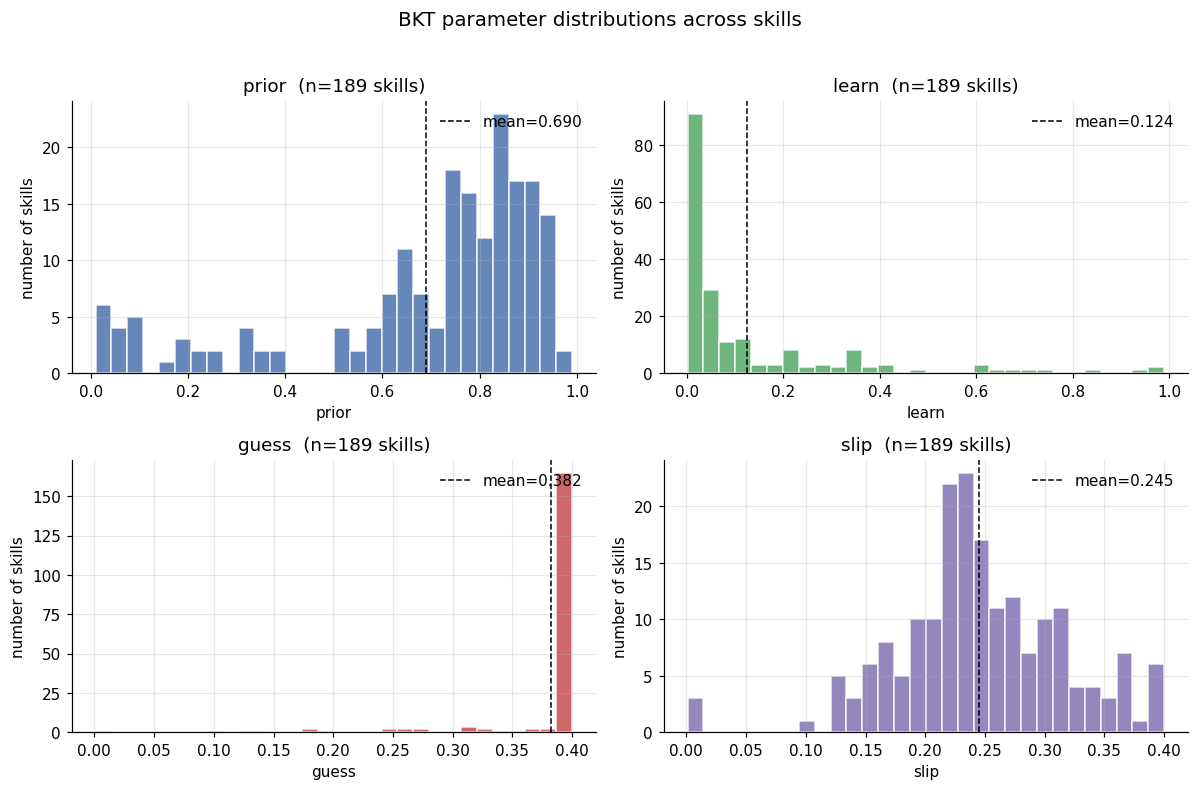

In [28]:
# ---- 1. Parameter distributions across skills ----
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, color in zip(
    axes.flat,
    ['prior', 'learn', 'guess', 'slip'],
    ['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
):
    ax.hist(params_df[col], bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(params_df[col].mean(), color='black', linestyle='--',
               linewidth=1, label=f"mean={params_df[col].mean():.3f}")
    ax.set_title(f"{col}  (n={len(params_df)} skills)")
    ax.set_xlabel(col)
    ax.set_ylabel('number of skills')
    ax.legend(loc='upper right', frameon=False)
fig.suptitle("BKT parameter distributions across skills", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


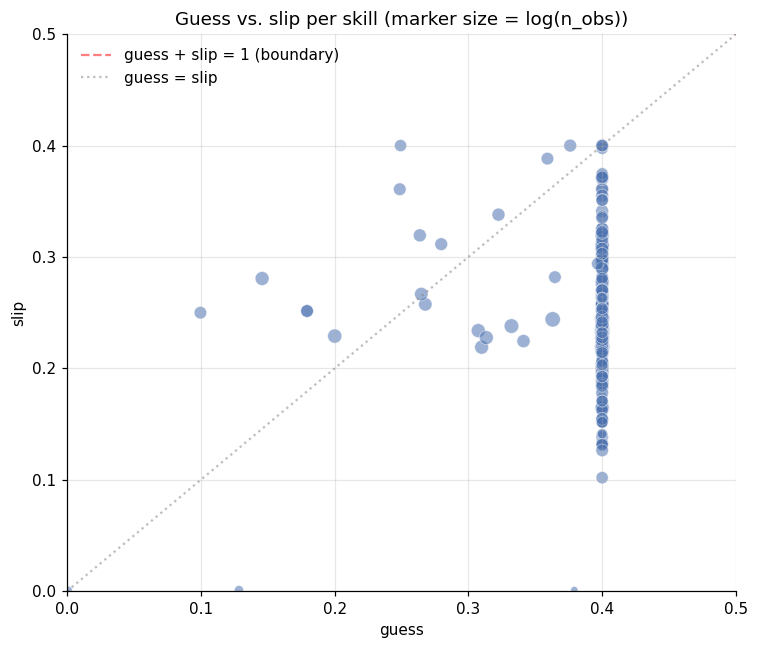

In [29]:
# ---- 2. Guess vs. slip scatter (BKT identifiability) ----
fig, ax = plt.subplots(figsize=(7, 6))
sizes = np.log1p(params_df['n_obs']) * 8 if 'n_obs' in params_df.columns else 40
ax.scatter(params_df['guess'], params_df['slip'],
           s=sizes, alpha=0.55, c='#4C72B0', edgecolor='white', linewidth=0.5)
# The line guess + slip = 1 is the BKT identifiability boundary
xs = np.linspace(0, 0.5, 50)
ax.plot(xs, 1 - xs, '--', color='red', alpha=0.5, label='guess + slip = 1 (boundary)')
ax.plot([0, 0.5], [0, 0.5], ':', color='gray', alpha=0.5, label='guess = slip')
ax.set_xlabel('guess'); ax.set_ylabel('slip')
ax.set_xlim(0, 0.5); ax.set_ylim(0, 0.5)
ax.set_title("Guess vs. slip per skill (marker size = log(n_obs))")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()


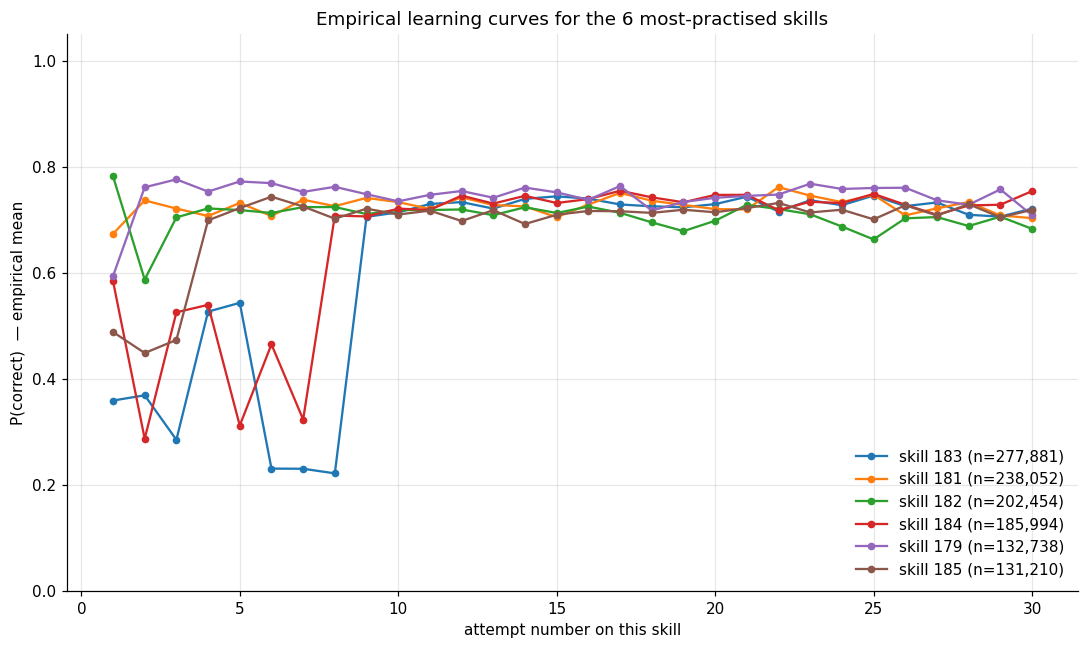

In [30]:
# ---- 3. Average empirical learning curves for top skills ----
top_skills = (df_bkt['skill_name'].value_counts()
              .head(6).index.tolist())

fig, ax = plt.subplots(figsize=(10, 6))
for skill in top_skills:
    sub = df_bkt[df_bkt['skill_name'] == skill].copy()
    # Re-number attempts WITHIN each (user, skill)
    sub['skill_attempt'] = sub.groupby('user_id').cumcount() + 1
    curve = sub.groupby('skill_attempt')['correct'].agg(['mean', 'count'])
    curve = curve[curve['count'] >= 20]   # only plot bins with enough students
    ax.plot(curve.index[:30], curve['mean'].values[:30],
            marker='o', markersize=4, label=f"skill {skill} (n={len(sub):,})")
ax.set_xlabel('attempt number on this skill')
ax.set_ylabel('P(correct)  — empirical mean')
ax.set_title("Empirical learning curves for the 6 most-practised skills")
ax.legend(frameon=False, loc='lower right')
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()


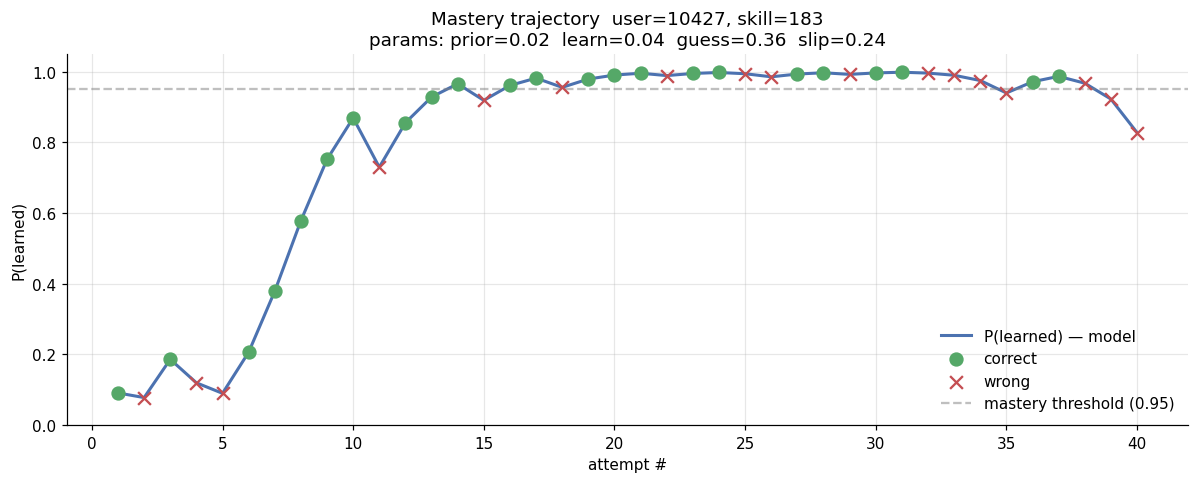

In [31]:
# ---- 4. Mastery trajectory for a single student-skill pair ----
# Pick a (user, skill) pair with a reasonably long sequence
candidates = (df_bkt.groupby(['user_id', 'skill_name']).size()
              .reset_index(name='n')
              .query('n >= 15 and n <= 40')
              .sort_values('n', ascending=False))

if len(candidates) > 0:
    pick = candidates.iloc[0]
    u, sk = int(pick['user_id']), pick['skill_name']
    sub = (df_bkt[(df_bkt['user_id'] == u) & (df_bkt['skill_name'] == sk)]
           .sort_values('order_id'))
    obs = sub['correct'].tolist()
    p = bkt_params[sk]

    # Track P(L) AFTER each observation (not before, like predictions)
    p_l_trace = []
    p_l = p['prior']
    for c in obs:
        if c == 1:
            num = p_l * (1 - p['slip'])
            den = num + (1 - p_l) * p['guess']
        else:
            num = p_l * p['slip']
            den = num + (1 - p_l) * (1 - p['guess'])
        p_l_post = num / den if den > 0 else p_l
        p_l = p_l_post + (1 - p_l_post) * p['learn']
        p_l_trace.append(p_l)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    xs = np.arange(1, len(obs) + 1)
    ax.plot(xs, p_l_trace, '-', color='#4C72B0', linewidth=2, label='P(learned) — model')
    ax.scatter(xs[np.array(obs) == 1], np.array(p_l_trace)[np.array(obs) == 1],
               marker='o', s=70, color='#55A868', label='correct', zorder=5)
    ax.scatter(xs[np.array(obs) == 0], np.array(p_l_trace)[np.array(obs) == 0],
               marker='x', s=70, color='#C44E52', label='wrong', zorder=5)
    ax.axhline(0.95, linestyle='--', color='gray', alpha=0.5, label='mastery threshold (0.95)')
    ax.set_xlabel('attempt #'); ax.set_ylabel('P(learned)')
    ax.set_title(f"Mastery trajectory  user={u}, skill={sk}\n"
                 f"params: prior={p['prior']:.2f}  learn={p['learn']:.2f}  "
                 f"guess={p['guess']:.2f}  slip={p['slip']:.2f}")
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=False, loc='lower right')
    plt.tight_layout(); plt.show()
else:
    print("No candidate (user, skill) pair with 15–40 attempts found.")


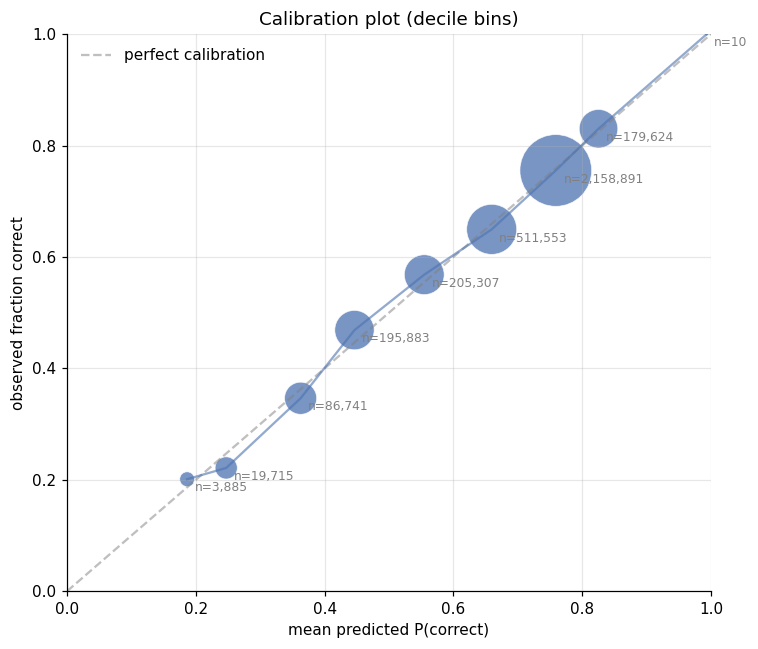

In [32]:
# ---- 5. Calibration plot: predicted vs observed ----
valid = df_predictions.dropna(subset=['correct_predictions']).copy()
# Bin predictions into deciles and compute observed P(correct) per bin
bins = np.linspace(0, 1, 11)
valid['pred_bin'] = pd.cut(valid['correct_predictions'], bins, include_lowest=True)
cal = valid.groupby('pred_bin', observed=True).agg(
    pred_mean=('correct_predictions', 'mean'),
    obs_mean=('correct', 'mean'),
    n=('correct', 'size'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='perfect calibration')
ax.scatter(cal['pred_mean'], cal['obs_mean'],
           s=np.sqrt(cal['n']) * 1.5, alpha=0.75,
           color='#4C72B0', edgecolor='white', linewidth=0.5)
ax.plot(cal['pred_mean'], cal['obs_mean'], '-', color='#4C72B0', alpha=0.6)
for _, row in cal.iterrows():
    ax.annotate(f"n={int(row['n']):,}", (row['pred_mean'], row['obs_mean']),
                xytext=(5, -8), textcoords='offset points', fontsize=8, color='gray')
ax.set_xlabel('mean predicted P(correct)')
ax.set_ylabel('observed fraction correct')
ax.set_title("Calibration plot (decile bins)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()
